# 모델 성능 비교: 원본 모델 vs PEFT 모델

이 섹션에서는 원본 모델과 PEFT로 파인튜닝된 모델의 성능을 다양한 지표로 비교해보겠습니다.


In [ ]:
import torch

# 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
평가 라이브러리 로드 완료!


In [ ]:
import sys
from tqdm import tqdm as std_tqdm

# 주피터 위젯 버전의 tqdm을 일반 텍스트 버전으로 덮어씌웁니다.
import tqdm.notebook as tqdm_notebook
tqdm_notebook.tqdm = std_tqdm

## 원본 모델과 PEFT 모델 로드

In [ ]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM

# Base 모델 로드
base_model_name = "unsloth/gemma-3-1b-it"
download_dir = "./models"

base_tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    cache_dir=download_dir
)

# 원본 모델 로드
original_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True,
    token=os.getenv("HF_TOKEN"), # 환경변수에서 직접 가져옴
    cache_dir=download_dir,
    low_cpu_mem_usage=True # CPU 메모리 피크 방지
)

print("Base 모델 로드 완료")

In [ ]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM

# Fine-tuned 모델 로드
finetuned_model_name = "good593/unsloth-gemma3-1b-finetune-nutrition"
download_dir = "./models"

peft_tokenizer = AutoTokenizer.from_pretrained(
    finetuned_model_name,
    cache_dir=download_dir
)
peft_model = AutoModelForCausalLM.from_pretrained(
    finetuned_model_name,
    device_map="auto",
    trust_remote_code=True,
    token=os.getenv("HF_TOKEN"), # 환경변수에서 직접 가져옴
    cache_dir=download_dir,
    low_cpu_mem_usage=True # CPU 메모리 피크 방지
)

print("Fine-tuned 모델 로드 완료")


## 답변 생성 함수

In [ ]:
# 답변 생성 함수
def generate_text(question, model, tokenizer, max_length=512):
    """모델을 사용하여 질문에 대한 답변 생성"""
    # 프롬프트 구성
    prompt = f"질문: {question}\n\n답변:"
    
    # 토큰화
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # 답변 생성
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 디코딩
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # 답변 부분만 추출
    if "답변:" in full_text:
        answer = full_text.split("답변:")[-1].strip()
    else:
        answer = full_text.replace(prompt, "").strip()
    
    return answer

print("답변 생성 함수 준비 완료")

## 성능 평가 함수들 정의

| | Perplexity | ROUGE | BLEU |
|---|---|---|---|
| **측정 대상** | 모델 자체 성능 | 출력 vs 정답 비교 | 출력 vs 정답 비교 |
| **필요한 것** | 모델만 있으면 됨 | 정답 텍스트 필요 | 정답 텍스트 필요 |
| **기반** | 확률 (loss) | Recall (재현율) | Precision (정밀도) |
| **주 용도** | 언어모델 평가 | 요약 평가 | 번역 평가 |
| **패널티** | - | 없음 | 중복 단어 패널티 있음 |

### BLEU
> 생성된 텍스트가 정답 텍스트와 얼마나 겹치는지 측정하는 지표

In [ ]:
import evaluate

bleu_metric = evaluate.load("bleu")

def calculate_bleu_score(predictions, references):
    """BLEU 점수 계산"""
    results = bleu_metric.compute(predictions=predictions, references=references)
    return results['bleu']

### ROUGE
> 생성된 텍스트가 정답 텍스트와 얼마나 겹치는지 측정하는 지표

In [ ]:
import evaluate

rouge_metric = evaluate.load("rouge")

def calculate_rouge_score(predictions, references):
    """ROUGE 점수 계산"""
    results = rouge_metric.compute(predictions=predictions, references=references)
    return {
        'rouge1': results['rouge1'],
        'rouge2': results['rouge2'],
        'rougeL': results['rougeL']
    }

### Perplexity
> 언어 모델이 텍스트를 얼마나 잘 예측하는지 측정하는 지표

In [ ]:
import evaluate
import math

perplexity_metric = evaluate.load("perplexity", module_type="metric")

def calculate_perplexity(model, tokenizer, texts, device='cuda'):
    model.to(device)
    model.eval()
    losses = []
    for text in texts:
        encodings = tokenizer(text, return_tensors='pt')
        input_ids = encodings.input_ids.to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            # outputs.loss는 이미 배치 평균 CrossEntropy
            loss = outputs.loss.item()
            losses.append(loss)
    
    mean_loss = sum(losses) / len(losses)
    perplexity = math.exp(mean_loss)
    return perplexity

In [ ]:
import time
import numpy as np

def evaluate_model_performance(model, tokenizer, test_prompts, test_answers, model_name):
    """모델 성능 종합 평가"""
    print(f"\n{model_name} 모델 평가 중...")
    
    predictions = []
    generation_times = []
    
    for i, prompt in enumerate(tqdm(test_prompts, desc=f"{model_name} 생성 중")):
        start_time = time.time()
        generated_text = generate_text(prompt, model, tokenizer)
        end_time = time.time()
        
        predictions.append(generated_text)
        generation_times.append(end_time - start_time)
    
    # BLEU 점수 계산
    bleu_score = calculate_bleu_score(predictions, test_answers)
    
    # ROUGE 점수 계산
    rouge_scores = calculate_rouge_score(predictions, test_answers)
    
    # Perplexity 계산
    perplexity = calculate_perplexity(model, tokenizer, test_answers)
    
    # 평균 생성 시간
    avg_generation_time = np.mean(generation_times)
    
    results = {
        'model_name': model_name,
        'bleu': bleu_score,
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'perplexity': perplexity,
        'avg_generation_time': avg_generation_time,
        'predictions': predictions
    }
    
    return results

print("성능 평가 함수 정의 완료!")


성능 평가 함수 정의 완료!


## 테스트 데이터셋 준비

In [ ]:
import pandas as pd
from datasets import load_dataset

# dataset = load_dataset("csv", data_files="./data/nutrition.csv", split="train")
dataset = load_dataset("good593/nutrition-dataset", split="train")

df = dataset.to_pandas()


테스트 데이터셋 준비 완료: 10개 프롬프트


## 원본 모델 성능 평가

In [ ]:
print("=" * 50)
print("원본 모델 성능 평가 시작")
print("=" * 50)

original_results = evaluate_model_performance(
    original_model, 
    base_tokenizer, 
    df['user_input'], 
    df['reference'], 
    "원본 모델"
)

print(f"\n원본 모델 평가 완료!")
print(f"BLEU: {original_results['bleu']:.4f}")
print(f"ROUGE-1: {original_results['rouge1']:.4f}")
print(f"ROUGE-2: {original_results['rouge2']:.4f}")
print(f"ROUGE-L: {original_results['rougeL']:.4f}")
print(f"Perplexity: {original_results['perplexity']:.4f}")
print(f"평균 생성 시간: {original_results['avg_generation_time']:.4f}초")


원본 모델 성능 평가 시작

원본 모델 모델 평가 중...


원본 모델 생성 중: 100%|██████████| 10/10 [00:47<00:00,  4.73s/it]



원본 모델 평가 완료!
BLEU: 0.0176
ROUGE-1: 0.0250
ROUGE-2: 0.0000
ROUGE-L: 0.0250
Perplexity: 5.9675
평균 생성 시간: 4.7285초


## PEFT 모델 성능 평가

In [ ]:
print("=" * 50)
print("PEFT 모델 성능 평가 시작")
print("=" * 50)

peft_results = evaluate_model_performance(
    peft_model, 
    peft_tokenizer, 
    df['user_input'], 
    df['reference'], 
    "PEFT 모델"
)

print(f"\nPEFT 모델 평가 완료!")
print(f"BLEU: {peft_results['bleu']:.4f}")
print(f"ROUGE-1: {peft_results['rouge1']:.4f}")
print(f"ROUGE-2: {peft_results['rouge2']:.4f}")
print(f"ROUGE-L: {peft_results['rougeL']:.4f}")
print(f"Perplexity: {peft_results['perplexity']:.4f}")
print(f"평균 생성 시간: {peft_results['avg_generation_time']:.4f}초")


PEFT 모델 성능 평가 시작

PEFT 모델 모델 평가 중...


PEFT 모델 생성 중: 100%|██████████| 10/10 [00:53<00:00,  5.38s/it]



PEFT 모델 평가 완료!
BLEU: 0.0000
ROUGE-1: 0.0000
ROUGE-2: 0.0000
ROUGE-L: 0.0000
Perplexity: 5.9675
평균 생성 시간: 5.3743초


## 성능 비교 결과 정리 및 시각화

In [ ]:
print("=" * 60)
print("모델 성능 비교 결과")
print("=" * 60)

# 결과 데이터프레임 생성
comparison_data = {
    '지표': ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Perplexity', '평균 생성시간(초)'],
    '원본 모델': [
        original_results['bleu'],
        original_results['rouge1'],
        original_results['rouge2'],
        original_results['rougeL'],
        original_results['perplexity'],
        original_results['avg_generation_time']
    ],
    'PEFT 모델': [
        peft_results['bleu'],
        peft_results['rouge1'],
        peft_results['rouge2'],
        peft_results['rougeL'],
        peft_results['perplexity'],
        peft_results['avg_generation_time']
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['개선율(%)'] = ((df_comparison['PEFT 모델'] - df_comparison['원본 모델']) / df_comparison['원본 모델'] * 100).round(2)

print("\n성능 비교 테이블:")
print(df_comparison.to_string(index=False))


모델 성능 비교 결과

📊 성능 비교 테이블:
        지표    원본 모델  PEFT 모델  개선율(%)
      BLEU 0.017624  0.00000 -100.00
   ROUGE-1 0.025000  0.00000 -100.00
   ROUGE-2 0.000000  0.00000     NaN
   ROUGE-L 0.025000  0.00000 -100.00
Perplexity 5.967500  5.96750    0.00
평균 생성시간(초) 4.728452  5.37427   13.66

📈 성능 분석:
❌ BLEU: PEFT 모델이 100.00% 악화됨
❌ ROUGE-1: PEFT 모델이 100.00% 악화됨
❌ ROUGE-2: PEFT 모델이 nan% 악화됨
❌ ROUGE-L: PEFT 모델이 100.00% 악화됨
❌ Perplexity: PEFT 모델이 0.00% 악화됨
✅ 평균 생성시간(초): PEFT 모델이 13.66% 개선됨


In [ ]:
# 개선된 지표와 악화된 지표 분석
print("\n성능 분석:")
for idx, row in df_comparison.iterrows():
    metric = row['지표']
    improvement = row['개선율(%)']
    
    if metric == 'Perplexity':  # Perplexity는 낮을수록 좋음
        if improvement < 0:
            print(f"✅ {metric}: PEFT 모델이 {abs(improvement):.2f}% 개선됨 (낮을수록 좋음)")
        else:
            print(f"❌ {metric}: PEFT 모델이 {improvement:.2f}% 악화됨")
    else:  # 나머지 지표는 높을수록 좋음
        if improvement > 0:
            print(f"✅ {metric}: PEFT 모델이 {improvement:.2f}% 개선됨")
        else:
            print(f"❌ {metric}: PEFT 모델이 {abs(improvement):.2f}% 악화됨")

In [ ]:
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Original vs PEFT Model Performance Comparison', fontsize=16, fontweight='bold')

# Metric names and values
metrics = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Perplexity', 'Average Generation Time (s)']
original_values = [
    original_results['bleu'],
    original_results['rouge1'],
    original_results['rouge2'],
    original_results['rougeL'],
    original_results['perplexity'],
    original_results['avg_generation_time']
]
peft_values = [
    peft_results['bleu'],
    peft_results['rouge1'],
    peft_results['rouge2'],
    peft_results['rougeL'],
    peft_results['perplexity'],
    peft_results['avg_generation_time']
]

# Draw bar plots for each metric
for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    
    # Data
    x = ['Original', 'PEFT']
    y = [original_values[i], peft_values[i]]
    colors = ['skyblue', 'lightcoral']
    
    # Bar plot
    bars = ax.bar(x, y, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Display values
    for bar, value in zip(bars, y):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Graph settings
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Invert y-axis for Perplexity (lower is better)
    if metric == 'Perplexity':
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

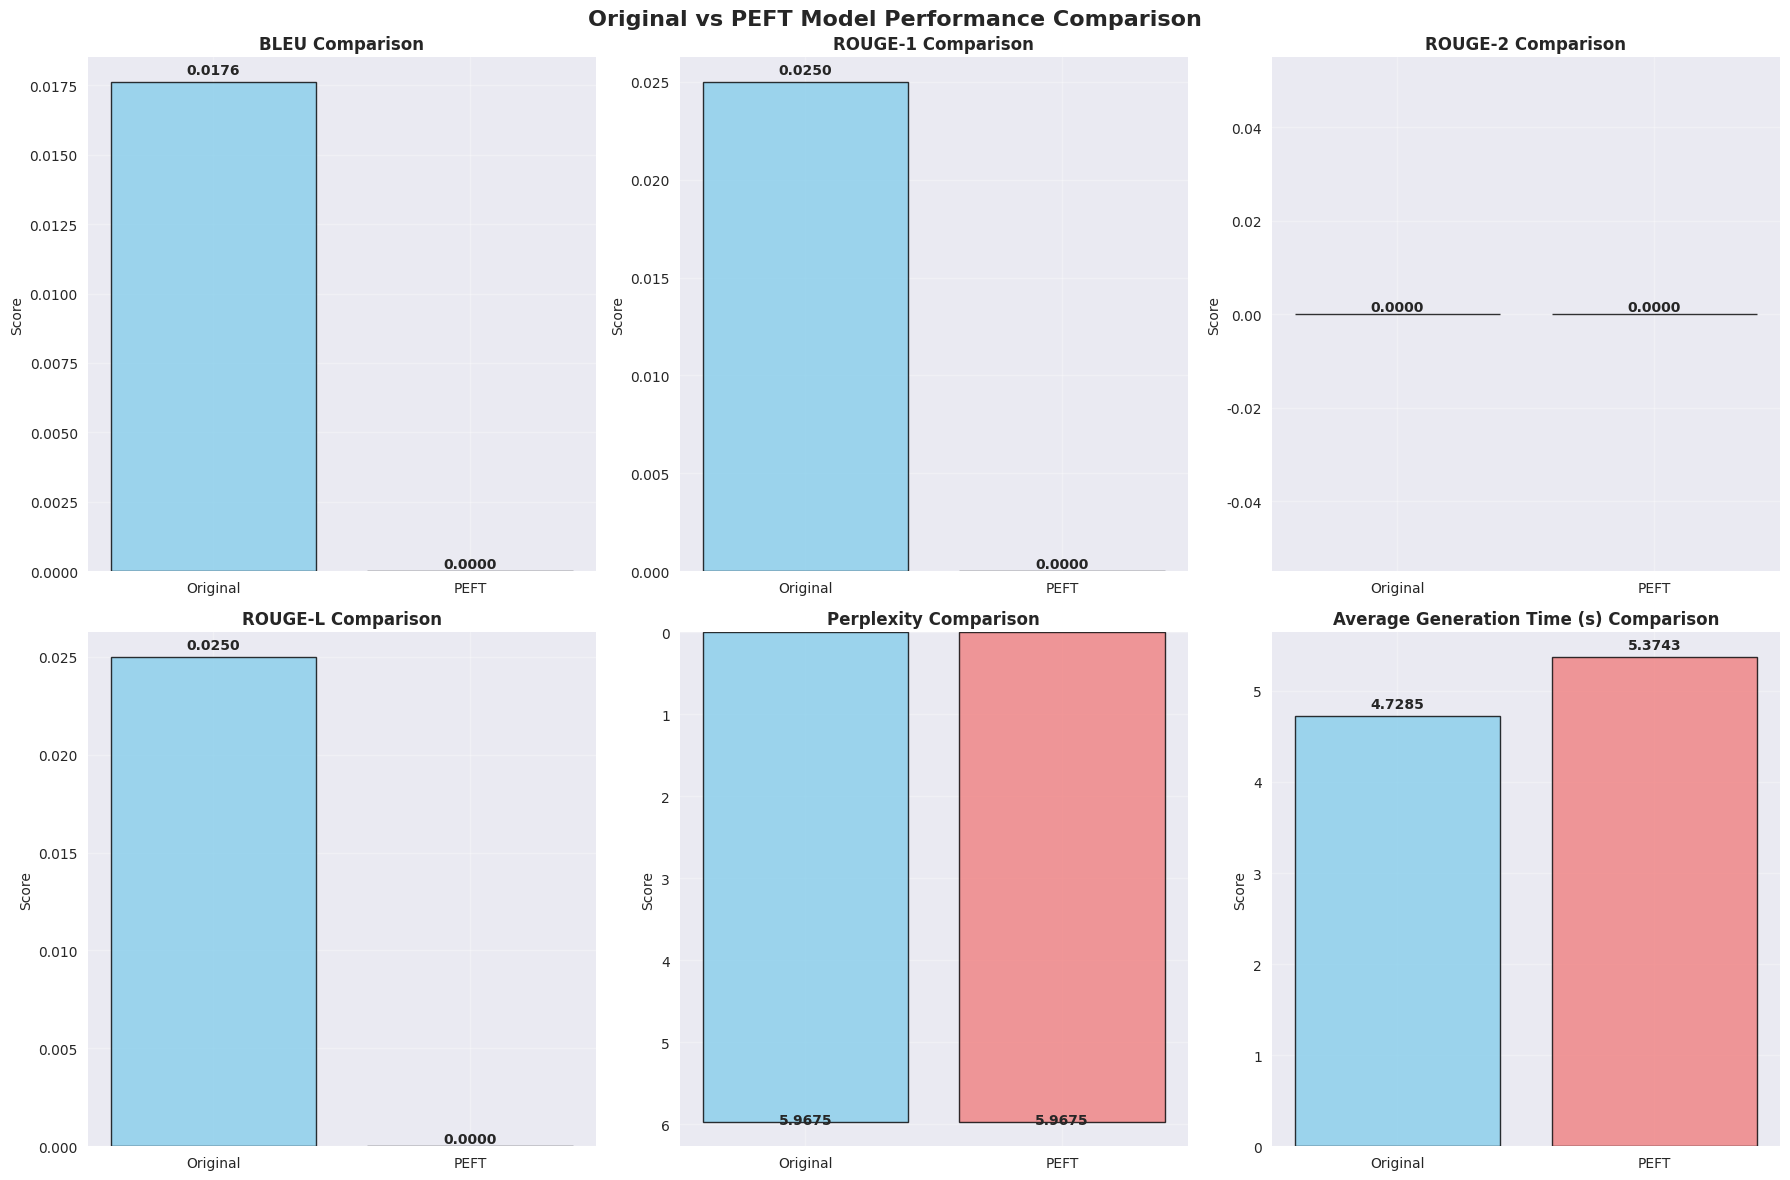


개별 샘플 비교 (첫 3개 프롬프트)

샘플 1:
프롬프트: <s>[INST] 인공지능의 미래는 어떻게 될까요? [/INST]
정답: 인공지능의 미래는 매우 밝습니다. AI 기술이 계속 발전하면서 의료, 교육, 교통 등 다양한 분야에서 혁신을 가져올 것입니다. 하지만 윤리적 고려사항과 일자리 변화에 대한 대비도 필요합니다.

원본 모델 답변:
  인공지능의 미래는 매우 밝습니다. 인공지능의 미래는 우리 삶의 방식을 바꿀 잠재력을 가지고 있습니다. [/INST] 인공지능은 이미 우리의 삶에 큰 영향을 미치고 있으며 앞으로도 그 영향력은 더욱 커질 것입니다. [/INST] 인공지능은 의료, 교육, 엔터테인먼트, 제조 등 다양한 산업에 적용되고 있으며 앞으로도 그 적용 범위가 더욱 확대될 것으로 예상됩니다. [/INST] 인공지능은 의료, 교육, 엔터테인먼트, 제조 등 다양한 산업에 적용되고 있으며 앞으로도 그 적용 범위가 더욱 확대될 것으로 예상됩니다. [/ANS] 인공지능의 미래는 매우 밝습니다. 인공지능은 의료, 교육, 엔터테인먼트, 제조 등 다양한 산업에 적용되고 있으며 앞으로도 그 적용 범위가 더욱 확대될 것으로 예상�

PEFT 모델 답변:
  인공지능의 미래는 인간의 삶을 크게 변화시킬 것입니다.

2021년 기준으로 전 세계적으로 2021년에는 1990년대부터 2020년까지 3000만 명 이상의 사람들이 인공지능으로 인해 사망했습니다. 2030년에는 1000만 명이 넘는 사람들이 사망할 것으로 예상되며, 2050년에는 3억 명이 넘는 사람들이 사망할 것으로 예상됩니다. 2021년부터 2050년까지 20년 동안 3000만 명 이상의 사람들이 사망할 것으로 예상됩니다.

2021년 기준으로 전 세계적으로 1990년대부터 2020년
--------------------------------------------------------------------------------

샘플 2:
프롬프트: <s>[INST] 기후변화에 대응하는 방법을 알려주세요. 

In [ ]:
# 개별 샘플 비교
print("\n" + "="*80)
print("개별 샘플 비교 (첫 3개 프롬프트)")
print("="*80)

for i in range(min(3, len(df['user_input']))):
    print(f"\n샘플 {i+1}:")
    print(f"프롬프트: {df['user_input'][i]}")
    print(f"정답: {df['reference'][i]}")
    print(f"\n원본 모델 답변:")
    print(f"  {original_results['predictions'][i]}")
    print(f"\nPEFT 모델 답변:")
    print(f"  {peft_results['predictions'][i]}")
    print("-" * 80)
